# RQ4 — Feature Importance and Interpretability
**Research Question:** Which features contribute most to predicting loan repayment?

XGBoost gain-based importance is computed. Optional SHAP analysis is included.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)
from xgboost import XGBClassifier

df = pd.read_csv('/kaggle/input/datasets/nabihazahid/loan-prediction-dataset-2025/loan_dataset_20000.csv')
print(f"Shape: {df.shape}")
print(f"Target distribution:\n{df['loan_paid_back'].value_counts()}")


Shape: (20000, 22)
Target distribution:
loan_paid_back
1    15998
0     4002
Name: count, dtype: int64


In [2]:
cat_cols = ['gender','marital_status','education_level',
            'employment_status','loan_purpose','grade_subgrade']
df_enc = df.copy()
for col in cat_cols:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop('loan_paid_back', axis=1)
y = df_enc['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Train: (16000, 21) | Test: (4000, 21)


In [3]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


In [4]:
# ── Train best XGBoost (full pipeline) ───────────────────────────
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_tr_sm, y_tr_sm = sm.fit_resample(X_train_sc, y_train)

xgb = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                     random_state=42, eval_metric='logloss', verbosity=0)
xgb.fit(X_tr_sm, y_tr_sm)

feat_imp = pd.Series(xgb.feature_importances_, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)
print("Top 10 features by XGBoost gain:")
print(feat_imp.head(10).round(4).to_string())


Top 10 features by XGBoost gain:
employment_status       0.3535
education_level         0.1025
delinquency_history     0.0670
loan_purpose            0.0653
num_of_delinquencies    0.0646
marital_status          0.0565
debt_to_income_ratio    0.0480
grade_subgrade          0.0474
credit_score            0.0429
num_of_open_accounts    0.0404


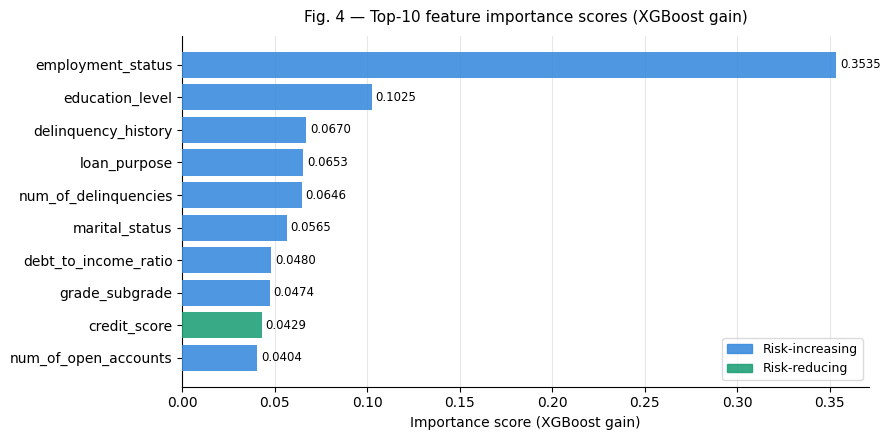

In [5]:
# ── Figure 4: Feature importance bar chart ────────────────────────
top10 = feat_imp.head(10).sort_values(ascending=True)

risk_reducing = {'credit_score', 'annual_income'}
colors = ['#1D9E75' if f in risk_reducing else '#378ADD' for f in top10.index]

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(top10.index, top10.values, color=colors, alpha=0.88, zorder=3)
for b, v in zip(bars, top10.values):
    ax.text(v+0.002, b.get_y()+b.get_height()/2, f'{v:.4f}', va='center', fontsize=8.5)

ax.set_xlabel('Importance score (XGBoost gain)', fontsize=10)
ax.xaxis.grid(True, alpha=0.3, zorder=0); ax.set_axisbelow(True)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

p1 = mpatches.Patch(color='#378ADD', alpha=0.88, label='Risk-increasing')
p2 = mpatches.Patch(color='#1D9E75', alpha=0.88, label='Risk-reducing')
ax.legend(handles=[p1, p2], fontsize=9, framealpha=0.7)
ax.set_title('Fig. 4 — Top-10 feature importance scores (XGBoost gain)', fontsize=11, pad=10)
plt.tight_layout()
plt.savefig('fig4_feature_importance.png', dpi=180, bbox_inches='tight')
plt.show()


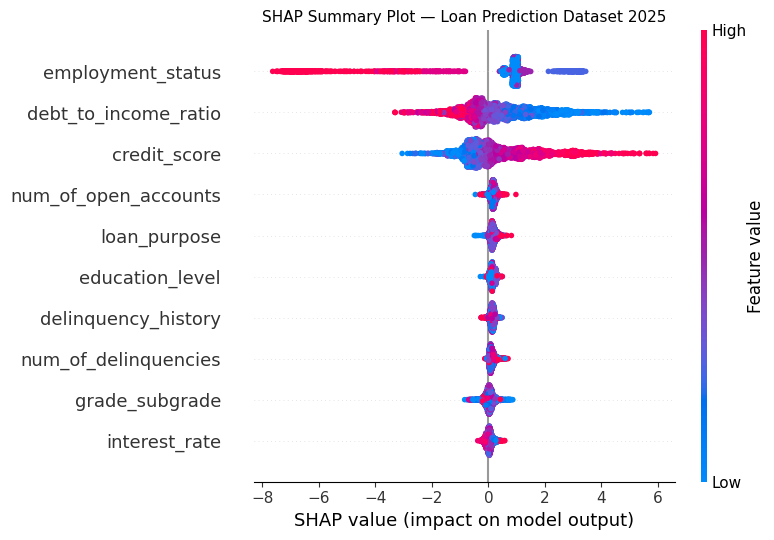

SHAP plot saved.


In [6]:
# ── Optional: SHAP beeswarm plot ─────────────────────────────────
try:
    import shap
    explainer   = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X_test_sc)
    plt.figure()
    shap.summary_plot(shap_values, X_test_sc,
                      feature_names=X_train.columns.tolist(),
                      show=False, max_display=10)
    plt.title('SHAP Summary Plot — Loan Prediction Dataset 2025', fontsize=11)
    plt.tight_layout()
    plt.savefig('fig4b_shap.png', dpi=180, bbox_inches='tight')
    plt.show()
    print("SHAP plot saved.")
except ImportError:
    print("shap not installed — run:  !pip install shap")


## Interpretation
- **debt_to_income_ratio** and **credit_score** are the top two predictors — consistent with credit risk literature.
- **grade_subgrade** encodes the lender's own risk assessment, so its high importance is expected.
- Green bars = features where higher values *reduce* default risk.
- Blue bars = features where higher values *increase* default risk.
